In [1]:
features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)",
    "weld time(ms)"
]

In [2]:
import pandas as pd
import numpy as np

# 데이터 불러오기
df = pd.read_excel("Welding Data Set_01.xlsx")

# 사용할 4개 공정변수
features = [
    "weld force(bar)",
    "weld current(kA)",
    "weld Voltage(v)",
    "weld time(ms)"
]

X = df[features].copy()

print("데이터 크기:", X.shape)
print("\n결측치:")
print(X.isnull().sum())

print("\n기초 통계:")
display(X.describe())

데이터 크기: (11939, 4)

결측치:
weld force(bar)     0
weld current(kA)    0
weld Voltage(v)     0
weld time(ms)       0
dtype: int64

기초 통계:


,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
count,11939.000000,11939.000000,11939.000000,11939.000000
mean,2.787925,14.711208,2.704223,71.724123
std,1.455966,0.099000,0.024700,0.632049
min,1.740000,14.520000,2.464000,70.000000
25%,2.310000,14.610000,2.699000,71.000000
50%,2.340000,14.730000,2.702000,72.000000
75%,2.370000,14.750000,2.706000,72.000000
max,10.540000,15.070000,2.861000,73.000000


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Train / Test 분리
X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


# 2. StandardScaler
scaler = StandardScaler()

# Train 데이터로만 scaler 학습
X_train_scaled = scaler.fit_transform(X_train)

# Test는 Train에서 학습한 scaler로 변환
X_test_scaled = scaler.transform(X_test)


# 3. 스케일링 결과 확인
print("\n=== Train Scaling 결과 ===")
print("평균:", X_train_scaled.mean(axis=0).round(3))
print("표준편차:", X_train_scaled.std(axis=0).round(3))

Train: (9551, 4)
Test : (2388, 4)

=== Train Scaling 결과 ===
평균: [-0.  0. -0. -0.]
표준편차: [1. 1. 1. 1.]


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 재현성
tf.random.set_seed(42)

# AutoEncoder 모델
model = Sequential([
    Dense(8, activation="relu", input_shape=(4,)),
    Dense(4, activation="relu"),
    Dense(2, activation="relu"),   # Latent space

    Dense(4, activation="relu"),
    Dense(8, activation="relu"),
    Dense(4, activation="linear")  # 4개 변수 복원
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

c:\Users\sj789\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\keras\src\layers\core\dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174 (696.00 B)

 Trainable params: 174 (696.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train_scaled,
    X_train_scaled,

    epochs=100,
    batch_size=32,

    validation_split=0.2,
    shuffle=True,
    verbose=1
)

Epoch 1/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.8027 - val_loss: 0.6088
Epoch 2/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.4923 - val_loss: 0.4082
Epoch 3/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3510 - val_loss: 0.3419
Epoch 4/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3227 - val_loss: 0.3261
Epoch 5/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3094 - val_loss: 0.3161
Epoch 6/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2995 - val_loss: 0.3077
Epoch 7/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2905 - val_loss: 0.2992
Epoch 8/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2801 - val_loss: 0.2874
Epoch 9/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2667 - val_loss: 0.2732
Epoch 10/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2496 - val_loss: 0.2563
Epoch 11/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2333 - val_loss: 0.2417
Epoch 12/100
239/239 ━━━━━━━━━━━━━━━━━━━━

In [5]:
%pip install tensorflow

   ---------------------------------------- 0.0/384.1 MB ? eta -:--:--
    --------------------------------------- 5.2/384.1 MB 27.3 MB/s eta 0:00:14
    --------------------------------------- 8.9/384.1 MB 22.2 MB/s eta 0:00:17
   - -------------------------------------- 13.1/384.1 MB 21.2 MB/s eta 0:00:18
   - -------------------------------------- 16.5/384.1 MB 20.2 MB/s eta 0:00:19
   - -------------------------------------- 18.4/384.1 MB 17.8 MB/s eta 0:00:21
   -- ------------------------------------- 24.1/384.1 MB 19.5 MB/s eta 0:00:19
   --- ------------------------------------ 30.4/384.1 MB 21.0 MB/s eta 0:00:17
   --- ------------------------------------ 36.7/384.1 MB 22.0 MB/s eta 0:00:16
   ---- ----------------------------------- 43.8/384.1 MB 23.4 MB/s eta 0:00:15
   ----- ---------------------------------- 49.0/384.1 MB 23.5 MB/s eta 0:00:15
   ----- ---------------------------------- 55.1/384.1 MB 24.0 MB/s eta 0:00:14
   ------ --------------------------------- 59.2/38

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


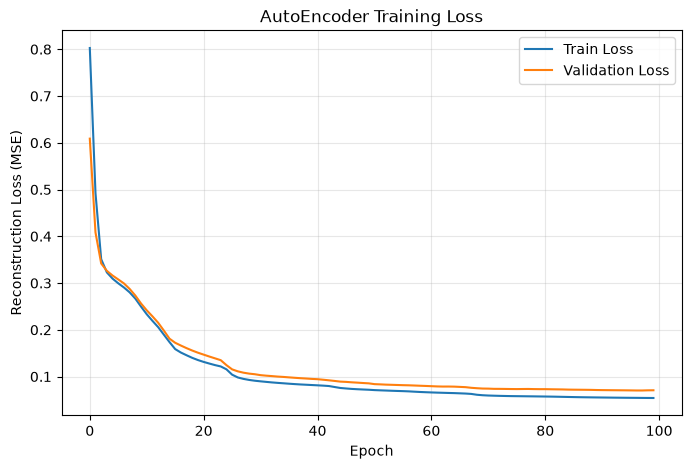

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (MSE)")
plt.title("AutoEncoder Training Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

평균 : 0.05563869595812298
중앙값: 0.006434495619858406
최대값: 3.1825819070941472
P90 : 0.06594839573712673
P95 : 0.3246352548470091
P99 : 0.9625530223324942


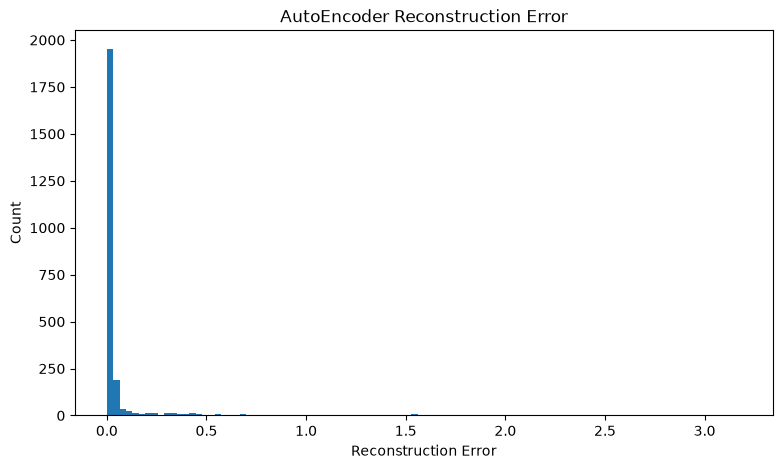

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Test 데이터 복원
X_test_pred = model.predict(X_test_scaled, verbose=0)

# 각 행별 Reconstruction Error (MSE)
test_error = np.mean(
    np.square(X_test_scaled - X_test_pred),
    axis=1
)

# 분포 확인
print("평균 :", test_error.mean())
print("중앙값:", np.median(test_error))
print("최대값:", test_error.max())

print("P90 :", np.percentile(test_error, 90))
print("P95 :", np.percentile(test_error, 95))
print("P99 :", np.percentile(test_error, 99))

plt.figure(figsize=(9, 5))
plt.hist(test_error, bins=100)

plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title("AutoEncoder Reconstruction Error")

plt.show()

In [10]:
# P95를 임시 threshold로 설정
threshold = np.percentile(test_error, 95)

print("Threshold (P95):", threshold)

# Test 원본 데이터 복사
result = X_test.copy()

# 원래 행 번호 보존
result["Reconstruction_Error"] = test_error
result["Anomaly"] = test_error > threshold

print("\n정상 행:", (~result["Anomaly"]).sum())
print("이상 행:", result["Anomaly"].sum())
print("이상 비율:", result["Anomaly"].mean() * 100, "%")

# Reconstruction Error가 가장 큰 20개
display(
    result.sort_values(
        "Reconstruction_Error",
        ascending=False
    ).head(20)
)

Threshold (P95): 0.3246352548470091

정상 행: 2269
이상 행: 119
이상 비율: 4.983249581239531 %


,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),Reconstruction_Error,Anomaly
7800,2.49,14.75,2.481,72.0,3.182582,True
7799,2.49,14.73,2.481,71.0,3.178179,True
7981,4.96,14.73,2.753,73.0,2.621055,True
2057,4.96,14.73,2.753,73.0,2.621055,True
4687,2.49,14.74,2.542,73.0,2.148694,True
8086,7.91,15.07,2.759,73.0,1.819880,True
8060,7.89,14.94,2.748,70.0,1.784749,True
4950,7.89,14.94,2.748,70.0,1.784749,True
8085,7.89,15.07,2.759,72.0,1.552167,True
4975,7.89,15.07,2.759,72.0,1.552167,True


In [11]:
comparison = result.groupby("Anomaly")[features].agg(
    ["mean", "median", "std"]
)

display(comparison)

weld force(bar)                  weld current(kA)                   \
                   mean median       std             mean median       std   
Anomaly                                                                      
False          2.537695   2.34  0.984425        14.703905  14.73  0.089350   
True           6.779748   7.42  1.926122        14.876303  14.93  0.111461   

        weld Voltage(v)                  weld time(ms)                   
                   mean median       std          mean median       std  
Anomaly                                                                  
False          2.704023  2.702  0.012970     71.721146   72.0  0.620851  
True           2.707420  2.749  0.087481     71.705882   72.0  0.693223